# Game Success Classifier
## Can we predict whether a video game will be critically acclaimed?

I wanted to try using functions and github for my own learning but this notebook should still run fine. 

**IOD Data Science & AI — Mini Project 03**
**Student:** Sean C
**GitHub:** [brighthikaru/game-success-classifier](https://github.com/brighthikaru/game-success-classifier) - 'private for now'
**Data Source:** [RAWG Video Games Database API](https://rawg.io/apidocs) — collected June 2026

## Business Understanding

The video game industry generates over $180 billion in revenue annually — larger than both the film and music industries combined. With thousands of games released every year across dozens of platforms, understanding what separates a critically acclaimed game from one that does not land has real commercial value for developers, publishers, and investors.

A strong Metacritic score drives visibility on storefronts, influences purchasing decisions, and can determine the commercial fate of a studio. But what actually predicts critical success before or at release?

This project uses data collected directly from the RAWG Video Games Database API — one of the largest open gaming databases in the world — to explore this question through machine learning.

**Business question:** Can we predict whether a video game will be critically acclaimed based on its characteristics at release?

We define a Hit as a game with a Metacritic score of 75 or above, representing broadly positive critical reception. Anything below 75 is classified as Not Hit — not a commercial failure necessarily, but not critically acclaimed.

| Class | Metacritic Score | Meaning |
|---|---|---|
| Hit | >= 75 | Broadly positive critical reception |
| Not Hit | < 75 | Mixed or negative critical reception |

## Project Structure (CRISP-DM)

| Phase | Section |
|---|---|
| Business Understanding | Above |
| Data Understanding | Section 1 — Load and Inspect |
| Data Preparation | Section 2 — Clean and Engineer Features |
| Exploratory Analysis | Section 3 — EDA |
| Modelling | Section 4 — Feature Matrix and Section 5 — Models |
| Evaluation | Section 6 — Comparison and Metrics |
| Tuning | Section 7 — Hyperparameter Optimisation |
| Insights | Section 8 — Feature Importance |
| Conclusion | Section 9 |

## Reusable Functions

A key design goal of this notebook is software engineering thinking — wrapping repeated logic into clean, reusable functions with clear inputs, outputs, and docstrings. Each function does one thing, takes clear inputs, and returns clear outputs.

| Function | Purpose |
|---|---|
| `load_and_inspect()` | Load any CSV and print a full data quality report |
| `engineer_features()` | Parse and transform raw columns into model-ready features |
| `plot_class_distribution()` | Plot target variable balance for any binary classification task |
| `build_feature_matrix()` | Encode and scale features, return X and y ready for modelling |
| `train_and_evaluate()` | Train any model and return a consistent metrics dictionary |
| `compare_models()` | Build a styled summary table and bar chart across all models |
| `run_grid_search()` | Run GridSearchCV with consistent settings and reporting |
| `plot_confusion_matrix()` | Plot a styled confusion matrix for any fitted model |
| `plot_feature_importance()` | Extract and plot feature importance — tree, linear, or (via permutation importance) any other fitted model |


## Imports and Configuration

In [1]:
# Standard library
import re
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance

# Scikit-learn: models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier,
)

# Scikit-learn: evaluation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc as sklearn_auc,
)

# Statsmodels — for statistical significance testing
import statsmodels.api as sm

warnings.filterwarnings("ignore")

# Global settings — random_state kept consistent throughout (lesson from MP02)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
DATA_PATH    = Path("../data/rawg_games.csv")

# Colour palette — consistent across all charts (SWD principles)
BLUE   = "#3B6EA5"
CORAL  = "#C45C3A"
GREEN  = "#2E7D5E"
GOLD   = "#E6A817"
GREY   = "#AAAAAA"
PURPLE = "#7B5EA7"
PALETTE = [BLUE, CORAL, GREEN, GOLD, GREY, PURPLE]

plt.rcParams.update({
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
})



## Section 1 — Data Loading and Inspection

We load the dataset collected from the RAWG Video Games Database API and run a full data quality inspection before modifying anything.

The data was collected using a custom Python script (`src/collect_rawg_data.py`) that called the RAWG API and saved results incrementally to CSV. The collection script is part of the project repository.

Note: the dataset covers games from 1980 to 2024 but is not a complete list for all years. The API returned limited data for more recent releases (2022 onwards) meaning the dataset skews toward historically reviewed titles rather than being fully representative of the current gaming landscape.

**Reusable function: `load_and_inspect()`**

Loads any CSV file and immediately reports shape, column types, missing values, and duplicate rows. Wrapping this as a function means we can run the same quality check on any dataset with a single call.


In [2]:
def load_and_inspect(filepath: Path) -> pd.DataFrame:
    """
    Load a CSV file and print a full data quality report.

    Parameters
    ----------
    filepath : Path
        Path to the CSV file to load.

    Returns
    -------
    pd.DataFrame
        The loaded dataframe.
    """
    df = pd.read_csv(filepath)

    print(f"Dataset : {filepath.name}")
    print(f"Rows    : {df.shape[0]:,}")
    print(f"Columns : {df.shape[1]}")
    print(f"Duplicates: {df.duplicated().sum():,}")
    print()
    print(f"  {'Column':<22} {'Type':<10} {'Nulls':>8}  {'Unique':>8}")
    print(f"  {'-'*52}")
    for col in df.columns:
        nulls  = df[col].isna().sum()
        unique = df[col].nunique()
        dtype  = str(df[col].dtype)
        print(f"  {col:<22} {dtype:<10} {nulls:>8,}  {unique:>8,}")

    return df


In [3]:
# Load the dataset
df_raw = load_and_inspect(DATA_PATH)


Dataset : rawg_games.csv
Rows    : 7,141
Columns : 16
Duplicates: 0

  Column                 Type          Nulls    Unique
  ----------------------------------------------------
  id                     int64             0     7,141
  name                   object            0     7,141
  released               object           17     3,809
  release_year           float64          17        42
  release_month          float64          17        12
  metacritic             int64             0        81
  rating                 float64           0       305
  rating_count           int64             0     1,010
  playtime               int64             0        91
  esrb_rating            object        2,387         6
  genres                 object           21       658
  platforms              object            3     1,057
  tags                   object          577     2,352
  developer              float64       7,141         0
  publisher              float64       7,141       

In [4]:
# Preview the first few rows
df_raw.head(3)


,id,name,released,release_year,release_month,metacritic,rating,rating_count,playtime,esrb_rating,genres,platforms,tags,developer,publisher,suggestions_count
0,25097,The Legend of Zelda: Ocarina of Time,1998-11-21,1998.0,11.0,99,4.38,882,7,Everyone,Adventure|Action|RPG,Nintendo Switch|Nintendo 64,Singleplayer,NaN,NaN,358
1,407559,Soulcalibur (1998),1998-07-30,1998.0,7.0,98,0.00,0,0,Teen,Fighting,Xbox 360|Dreamcast,NaN,NaN,NaN,0
2,54751,Soulcalibur,1998-07-30,1998.0,7.0,98,4.39,84,6,NaN,Action|Fighting,Xbox One|iOS|Android|Xbox 360|Dreamcast,2 players,NaN,NaN,426


In [5]:
# Sample key columns to understand the raw format
# genres, platforms, and tags are pipe-separated strings — not yet usable as features
print("Sample genres:")
print(df_raw['genres'].dropna().head(5).to_string())
print()
print("Sample platforms:")
print(df_raw['platforms'].dropna().head(5).to_string())
print()
print("Sample tags:")
print(df_raw['tags'].dropna().head(3).to_string())


Sample genres:
0        Adventure|Action|RPG
1                    Fighting
2             Action|Fighting
3    Shooter|Adventure|Action
4                  Platformer

Sample platforms:
0                Nintendo Switch|Nintendo 64
1                         Xbox 360|Dreamcast
2    Xbox One|iOS|Android|Xbox 360|Dreamcast
3                               Wii|GameCube
4                        Nintendo Switch|Wii

Sample tags:
0    Singleplayer
2       2 players
3    Singleplayer


**Observations:**

- Developer and publisher columns are empty — no data was returned from the API for these fields
- ESRB rating has a significant number of missing values — these will be filled as "Not Rated" during cleaning
- Tags and platforms have very high unique counts — too many combinations to use directly as features, so nee to engineer count-based features instead
- Genres, platforms, and tags are stored as pipe-separated strings — not usable by models directly and need to be parsed
- Release year and month have some missing values — will be filled with the median during cleaning
- Low unique count columns like ESRB rating and release year are good candidates for encoding as categorical features


## Section 2 — Data Cleaning and Feature Engineering

Raw data from APIs is rarely model-ready. This section transforms the raw RAWG data into a clean feature matrix suitable for machine learning.

**Cleaning tasks:**

1. Parse pipe-separated columns — genres, platforms, and tags are stored as "Action|RPG|Adventure" strings. We extract the primary value and engineer count features from each.
2. Clean tags — the tags column contains mixed English and Russian text from RAWG's international user base. We filter to English-only tags.
3. Handle missing ESRB ratings — 33% of games have no ESRB rating recorded. We encode these as "Not Rated" rather than dropping the rows.
4. Log-transform playtime — high playtime is genuine signal in gaming (a player logging 500 hours in an RPG is expected, not an outlier). We apply a log transformation to compress the right-skewed distribution without discarding any data.
5. Engineer release features — we extract release year and create an `is_holiday_release` flag for November and December releases, which historically perform differently.
6. Build the target variable — `hit = 1` if Metacritic >= 75, else `hit = 0`.

**Reusable function: `engineer_features()`**

Encapsulating all feature engineering in one function ensures the same transformations are applied consistently, and makes the logic easy to reuse on future gaming datasets.


In [6]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and engineer features from the raw RAWG dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Raw dataframe as loaded from rawg_games.csv.

    Returns
    -------
    pd.DataFrame
        Cleaned dataframe with engineered features and target variable added.

    Features engineered
    -------------------
    primary_genre      : First (most prominent) genre listed
    n_genres           : Number of genres assigned to the game
    primary_platform   : First platform listed
    n_platforms        : Number of platforms (multi-platform suggests larger budget)
    primary_tag        : First English-language tag
    n_tags             : Number of English tags
    esrb_clean         : ESRB rating with nulls filled as 'Not Rated'
    playtime_log       : Log-transformed playtime — preserves high-engagement signal
    is_holiday_release : 1 if released in November or December
    release_year       : Year of release
    hit                : Target variable — 1 if metacritic >= 75, else 0
    """
    df = df.copy()

    # Parse pipe-separated genre column
    df['genres'] = df['genres'].fillna("")
    df['primary_genre'] = df['genres'].apply(
        lambda x: x.split("|")[0].strip() if x else "Unknown"
    )
    df['n_genres'] = df['genres'].apply(
        lambda x: len(x.split("|")) if x else 0
    )

    # Parse pipe-separated platform column
    df['platforms'] = df['platforms'].fillna("")
    df['primary_platform'] = df['platforms'].apply(
        lambda x: x.split("|")[0].strip() if x else "Unknown"
    )
    df['n_platforms'] = df['platforms'].apply(
        lambda x: len(x.split("|")) if x else 0
    )

    # Parse tags — keep English only (filter out Cyrillic characters)
    def extract_english_tags(tag_string):
        """Return only tags that contain no Cyrillic characters."""
        if not isinstance(tag_string, str) or tag_string == "":
            return []
        tags = tag_string.split("|")
        return [t.strip() for t in tags if not re.search(r'[а-яА-ЯёЁ]', t)]

    df['tags_clean']  = df['tags'].apply(extract_english_tags)
    df['primary_tag'] = df['tags_clean'].apply(lambda x: x[0] if x else "Unknown")
    df['n_tags']      = df['tags_clean'].apply(len)

    # ESRB rating — fill nulls as 'Not Rated'
    df['esrb_clean'] = df['esrb_rating'].fillna("Not Rated")

    # Log-transform playtime — high playtime is genuine signal (e.g. 500hrs in Civilisation is normal and meaningful). Capping would destroy that signal. Instead we apply
    # log1p (log(1 + x)) which compresses the long tail while preserving the ranking.
    # log1p handles zeros safely — log1p(0) = 0.
    df['playtime_log'] = np.log1p(df['playtime'])

    # Holiday release flag — November and December releases
    df['release_month']      = pd.to_numeric(df['release_month'], errors='coerce').fillna(0).astype(int)
    df['is_holiday_release'] = df['release_month'].isin([11, 12]).astype(int)

    # Release year — clean and fill missing with median
    df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
    df['release_year'] = df['release_year'].fillna(df['release_year'].median()).astype(int)

    # Target variable
    df['hit'] = (df['metacritic'] >= 75).astype(int)

    return df


In [7]:
# Apply feature engineering
df = engineer_features(df_raw)

print(f"Shape after engineering: {df.shape}")
print()
print("New columns added:")
new_cols = [
    'primary_genre', 'n_genres', 'primary_platform', 'n_platforms',
    'primary_tag', 'n_tags', 'esrb_clean', 'playtime_log',
    'is_holiday_release', 'release_year', 'hit',
]
for col in new_cols:
    print(f"  {col:<25} {str(df[col].dtype):<10}  nulls: {df[col].isna().sum()}")


Shape after engineering: (7141, 27)

New columns added:
  primary_genre             object      nulls: 0
  n_genres                  int64       nulls: 0
  primary_platform          object      nulls: 0
  n_platforms               int64       nulls: 0
  primary_tag               object      nulls: 0
  n_tags                    int64       nulls: 0
  esrb_clean                object      nulls: 0
  playtime_log              float64     nulls: 0
  is_holiday_release        int64       nulls: 0
  release_year              int64       nulls: 0
  hit                       int64       nulls: 0


In [8]:
# Target variable distribution
print("Target variable — Hit vs Not Hit:")
print(df['hit'].value_counts().rename({1: 'Hit (>=75)', 0: 'Not Hit (<75)'}).to_string())
print(f"\nClass balance: {df['hit'].mean()*100:.1f}% Hit")


Target variable — Hit vs Not Hit:
hit
Not Hit (<75)    3767
Hit (>=75)       3374

Class balance: 47.2% Hit


**Feature engineering summary:**

- New columns were engineered from the raw data to make it usable for modelling — primary genre, platform, and tag were extracted from pipe-separated strings, and count features were created for each
- Playtime was log-transformed to handle the right-skewed distribution without losing the signal that high engagement games carry
- Missing ESRB ratings were filled as "Not Rated" rather than dropping rows
- Missing release year and month values were filled with the median
- All engineered columns have zero nulls — the dataset is clean and ready for modelling
- String columns like primary_genre and esrb_clean will be label encoded in the next step before being passed to the models
- The target variable is nearly balanced at 47% Hit and 53% Not Hit — no resampling needed


## Section 3 — Exploratory Data Analysis

Before building models we visualise the data to understand distributions, class balance, and which features look most predictive of critical success. Every chart is followed by an insight note explaining what it means for modelling.

**Reusable function: `plot_class_distribution()`**


In [9]:
def plot_class_distribution(y: pd.Series,
                            labels: dict = None,
                            title: str = "Target Variable Distribution",
                            colours: list = None) -> None:
    """
    Plot the distribution of a binary target variable as a bar chart and pie chart.

    Parameters
    ----------
    y : pd.Series
        Binary target variable (0/1 values).
    labels : dict, optional
        Mapping of {0: 'Label A', 1: 'Label B'} for display.
    title : str
        Chart title.
    colours : list, optional
        Two colours for the bars. Defaults to CORAL and BLUE.
    """
    if colours is None:
        colours = [CORAL, BLUE]
    if labels is None:
        labels = {0: "Class 0", 1: "Class 1"}

    counts = y.value_counts().sort_index().rename(labels)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    bars = axes[0].bar(counts.index, counts.values,
                       color=colours, edgecolor="white", width=0.5)
    for bar, val in zip(bars, counts.values):
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 30,
                     f"{val:,}", ha="center", fontsize=10)
    axes[0].set_title(title, fontweight="bold")
    axes[0].set_ylabel("Count")

    axes[1].pie(counts.values, labels=counts.index,
                colors=colours, autopct="%1.1f%%",
                startangle=90, wedgeprops={"edgecolor": "white"})
    axes[1].set_title("Class balance", fontweight="bold")

    plt.tight_layout()
    plt.savefig("../outputs/class_distribution.png", bbox_inches="tight")
    plt.show()


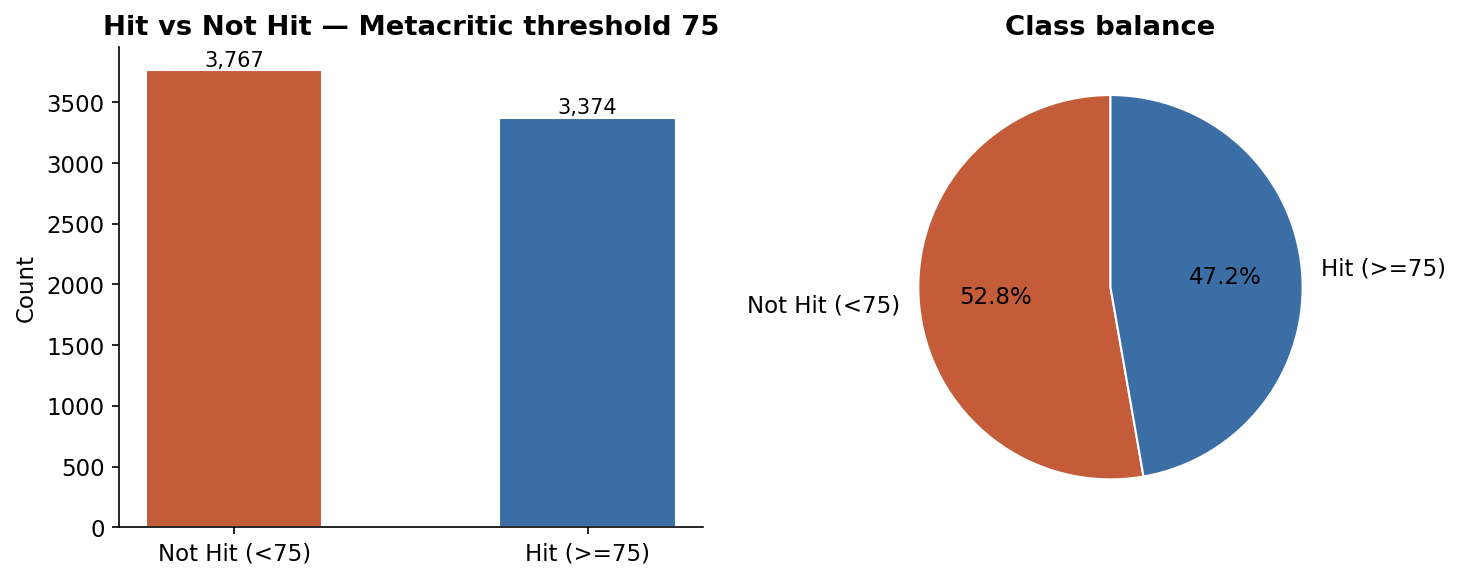

In [10]:
# 3.1 Target variable distribution
plot_class_distribution(
    df['hit'],
    labels={0: "Not Hit (<75)", 1: "Hit (>=75)"},
    title="Hit vs Not Hit — Metacritic threshold 75",
)


**Insight:** 

- The dataset is nearly balanced at 47/53 which means the models will have sufficient examples of both classes to learn from
- Macro F1 is a reliable metric here as both classes are well represented
- If the dataset were heavily imbalanced we would need techniques like class weighting or resampling to prevent the model from simply predicting the majority class


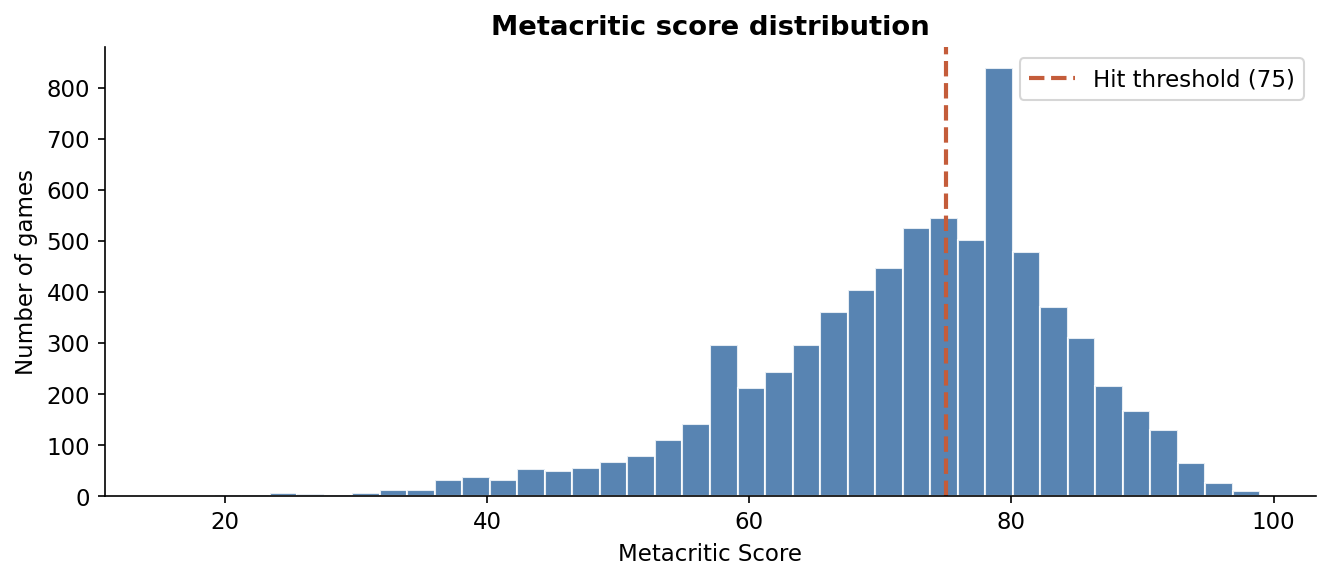

In [11]:
# 3.2 Metacritic score distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['metacritic'], bins=40, color=BLUE, edgecolor="white", alpha=0.85)
ax.axvline(75, color=CORAL, linestyle="--", linewidth=2, label="Hit threshold (75)")
ax.set_title("Metacritic score distribution", fontweight="bold")
ax.set_xlabel("Metacritic Score")
ax.set_ylabel("Number of games")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/metacritic_distribution.png", bbox_inches="tight")
plt.show()


**Insight:** 

- The metacritic distribution shows that our API retrieval captured only games that had a metacritic score between 1 and 100.
- These games were rated by critics, so any lesser known games without an official review were not collected.
- It also shows that a lot of the games are around 75-85 in metacritic score, indicating that the games are generally well-received by critics in this dataset.


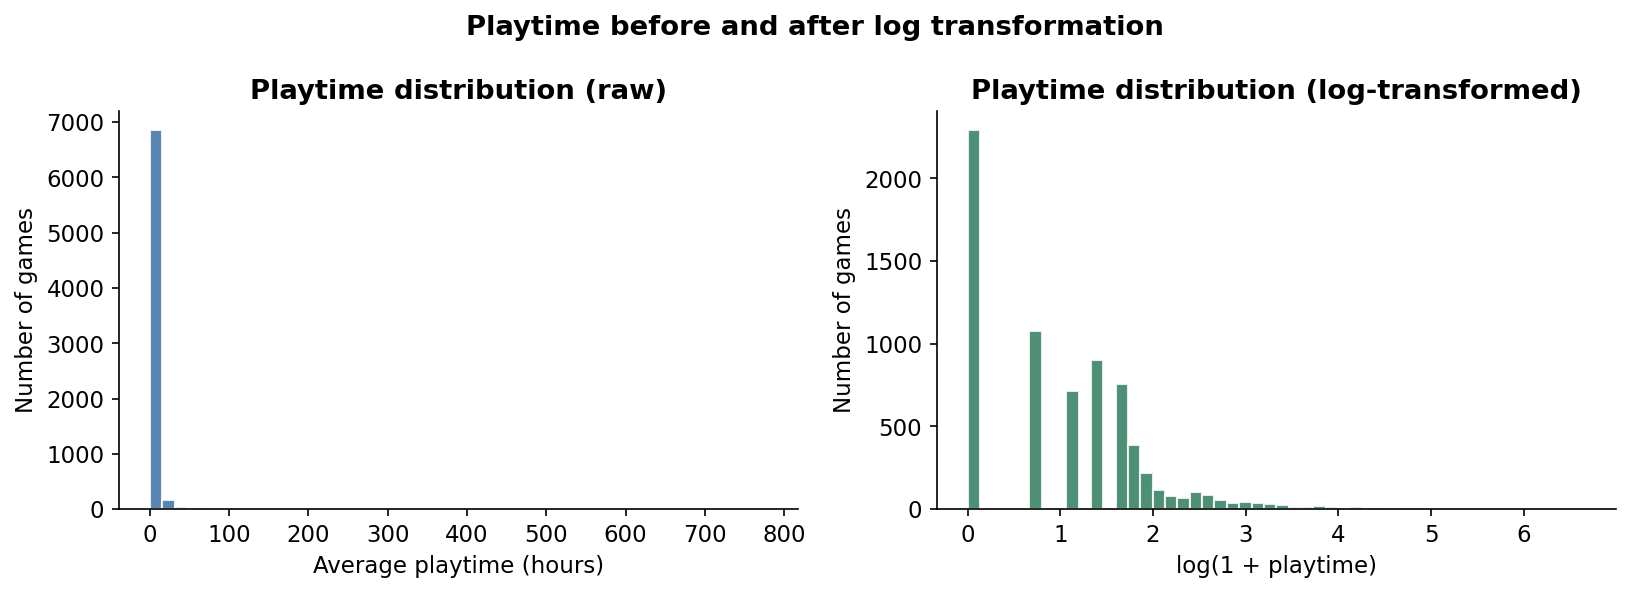

Raw playtime   — mean: 3.9h  median: 2.0h  max: 778h
Log playtime   — mean: 1.02  median: 1.10  max: 6.66


In [12]:
# 3.3 Playtime distribution — log scale
# High playtime is natural and expected (e.g. RPGs, MMOs, strategy games)
# We use log scale on the x-axis to show the full range clearly
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Raw playtime distribution
axes[0].hist(df['playtime'], bins=50, color=BLUE, edgecolor="white", alpha=0.85)
axes[0].set_title("Playtime distribution (raw)", fontweight="bold")
axes[0].set_xlabel("Average playtime (hours)")
axes[0].set_ylabel("Number of games")

# Log-transformed distribution
axes[1].hist(df['playtime_log'], bins=50, color=GREEN, edgecolor="white", alpha=0.85)
axes[1].set_title("Playtime distribution (log-transformed)", fontweight="bold")
axes[1].set_xlabel("log(1 + playtime)")
axes[1].set_ylabel("Number of games")

plt.suptitle("Playtime before and after log transformation", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/playtime_distribution.png", bbox_inches="tight")
plt.show()

print(f"Raw playtime   — mean: {df['playtime'].mean():.1f}h  median: {df['playtime'].median():.1f}h  max: {df['playtime'].max():.0f}h")
print(f"Log playtime   — mean: {df['playtime_log'].mean():.2f}  median: {df['playtime_log'].median():.2f}  max: {df['playtime_log'].max():.2f}")


**Insight:** 
The raw playtime distribution is heavily right-skewed — most games have low average playtime which could be due to not being recorded, but some titles (open-world RPGs, strategy games, MMOs) naturally attract hundreds of hours of play. This is not an outlier problem — it is genuine signal. The 0 playtime is because not all users logged it on RAWG or they own the game and haven't played it yet.

A log transformation compresses the scale without removing data. That said, `playtime_log` ends up excluded from the model — see Section 4. RAWG's playtime figure is a running average built from user play sessions logged after release, so like `rating_count`, it isn't knowable at or before a game's launch. We keep it here for EDA because it's a genuinely interesting engagement signal, just not a legitimate prediction feature for this project's business question.

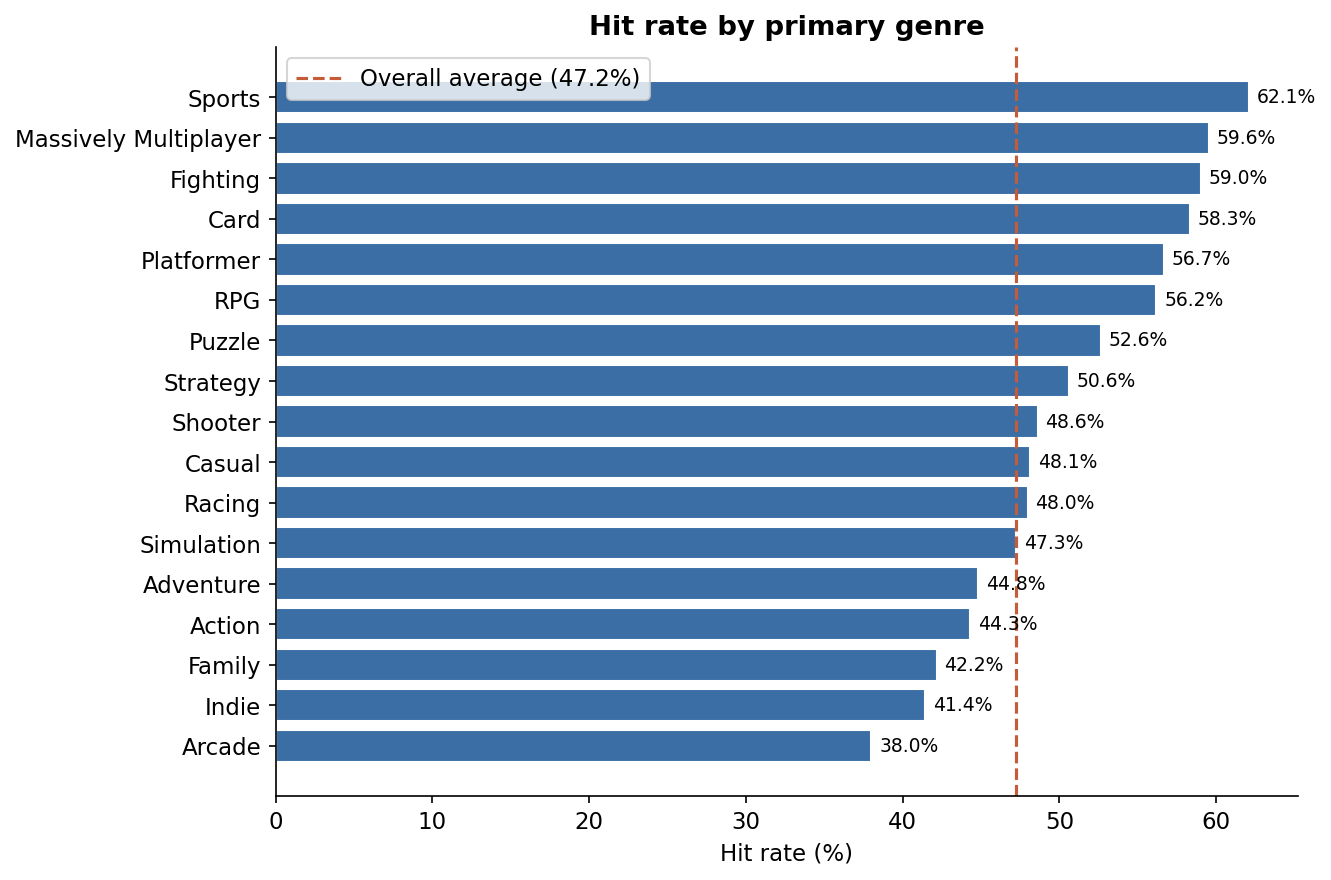

In [13]:
# 3.3 Hit rate by genre
genre_hit = (df.groupby('primary_genre')['hit']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'hit_rate', 'count': 'total'})
               .query('total >= 30')
               .sort_values('hit_rate', ascending=True))

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(genre_hit.index, genre_hit['hit_rate'] * 100,
               color=BLUE, edgecolor="white")
for bar, val in zip(bars, genre_hit['hit_rate'] * 100):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)
ax.axvline(df['hit'].mean() * 100, color=CORAL, linestyle="--",
           linewidth=1.5, label=f"Overall average ({df['hit'].mean()*100:.1f}%)")
ax.set_xlabel("Hit rate (%)")
ax.set_title("Hit rate by primary genre", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/hit_rate_by_genre.png", bbox_inches="tight")
plt.show()


**Insight:** 

- Sports and MMO games top the hit rate chart — these are predominantly made by large, established studios with big budgets, which translates to higher production quality and more consistent critical acclaim
- Online and multiplayer games in these genres attract more critic attention and tend to be more polished at release
- Action and Adventure games surprisingly sit below the overall average despite being the most popular genre — this is explained by volume, the sheer number of action games released means quality varies widely, pulling the average hit rate down
- Arcade, indie, and family genres sit at the lower end — smaller budgets and less critic coverage likely contribute to lower average scores

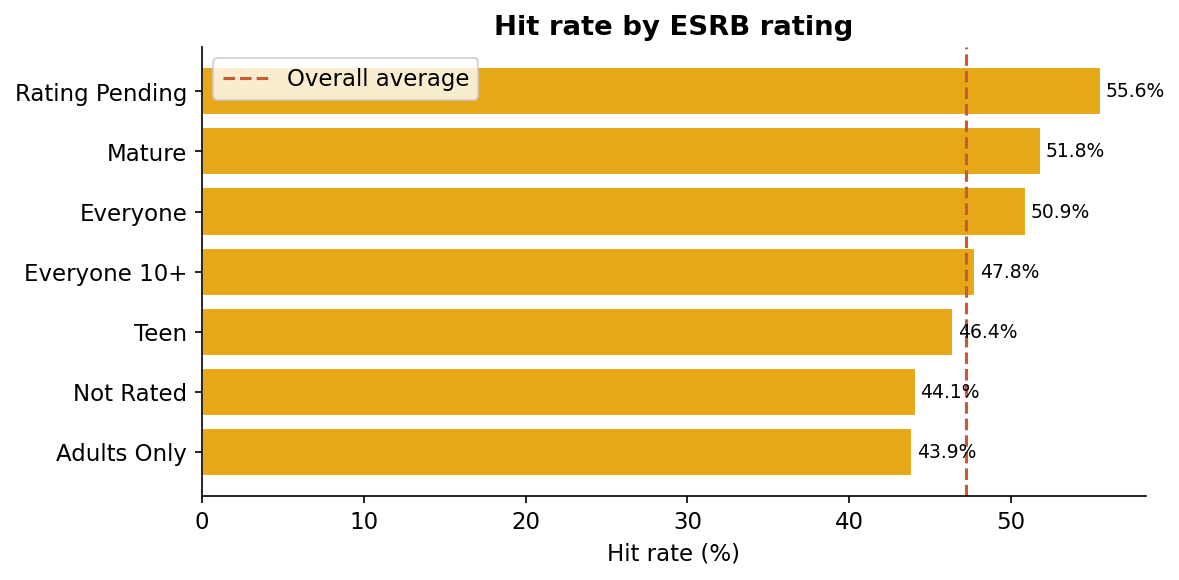

In [14]:
# 3.4 Hit rate by ESRB rating
esrb_hit = (df.groupby('esrb_clean')['hit']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'hit_rate', 'count': 'total'})
              .sort_values('hit_rate', ascending=True))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(esrb_hit.index, esrb_hit['hit_rate'] * 100,
               color=GOLD, edgecolor="white")
for bar, val in zip(bars, esrb_hit['hit_rate'] * 100):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)
ax.axvline(df['hit'].mean() * 100, color=CORAL, linestyle="--",
           linewidth=1.5, label="Overall average")
ax.set_xlabel("Hit rate (%)")
ax.set_title("Hit rate by ESRB rating", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/hit_rate_by_esrb.png", bbox_inches="tight")
plt.show()


**Insight:**

- Games with a Mature rating have the highest hit rate, likely reflecting that M-rated games tend to come from larger studios with bigger budgets targeting adult audiences
- E-rated games sit around the average — this category is mixed, containing both big budget sports titles and smaller casual games which balances out the hit rate
- A large number of games show Pending ratings despite being released games — this is a data quality issue suggesting RAWG did not always capture the final ESRB rating after release
- Not Rated and Adults Only sit below average but represent very small sample sizes so conclusions are limited
- ESRB rating will be kept as a feature for now and its actual predictive value will be assessed in the feature importance analysis later


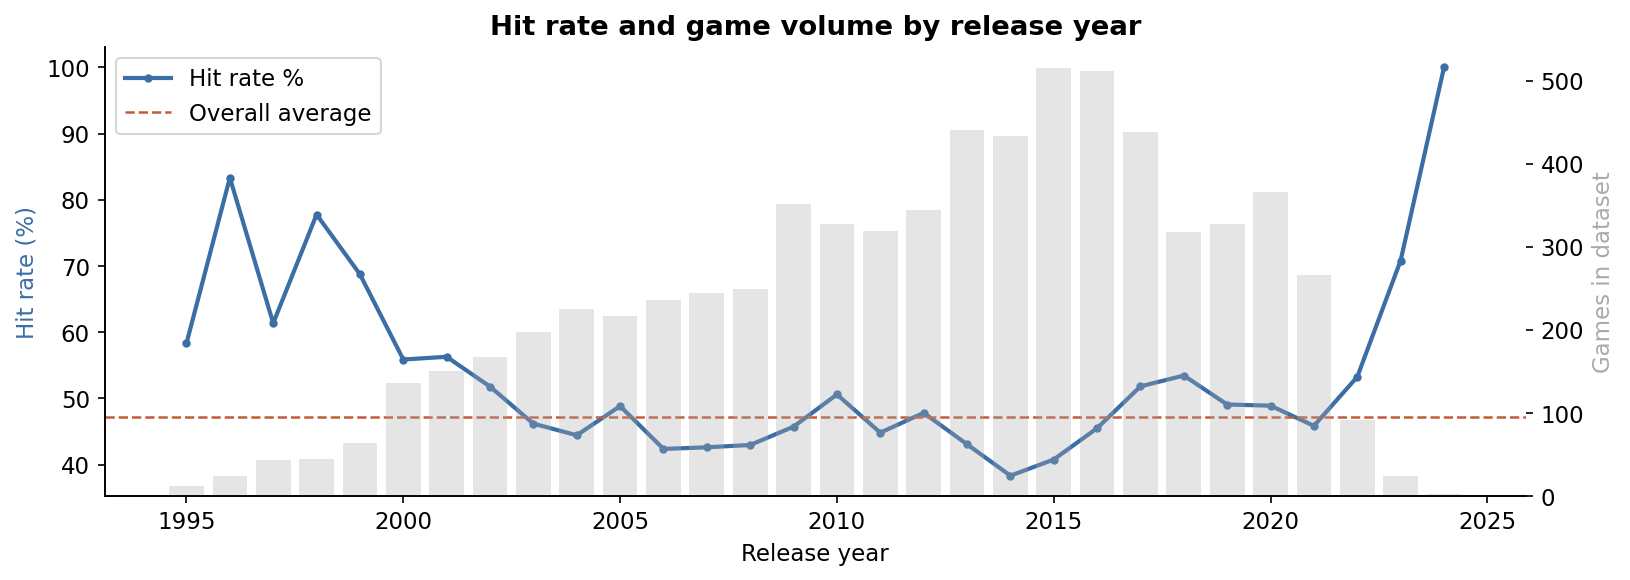

In [15]:
# 3.5 Hit rate trend by release year
year_hit = (df[df['release_year'] >= 1995]
              .groupby('release_year')['hit']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'hit_rate', 'count': 'total'}))

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

ax1.plot(year_hit.index, year_hit['hit_rate'] * 100,
         color=BLUE, linewidth=2, marker='o', markersize=3, label="Hit rate %")
ax2.bar(year_hit.index, year_hit['total'], color=GREY, alpha=0.3, label="Games in dataset")
ax1.axhline(df['hit'].mean() * 100, color=CORAL, linestyle="--",
            linewidth=1.2, label="Overall average")

ax1.set_ylabel("Hit rate (%)", color=BLUE)
ax2.set_ylabel("Games in dataset", color=GREY)
ax1.set_xlabel("Release year")
ax1.set_title("Hit rate and game volume by release year", fontweight="bold")
ax1.legend(loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/hit_rate_by_year.png", bbox_inches="tight")
plt.show()


**Insight:**

- Hit rate was high in the 1990s because fewer games were released and only notable titles got reviewed by critics, pushing the average up
- As the gaming industry grew through the 2000s and 2010s, more games of varying quality entered the market which pulled the average hit rate down — the same logic as the action genre saturation
- The apparent drop after 2020 is not a real trend but a collection bias — the dataset does not have a complete list of games for more recent years as the RAWG API returned limited data for 2022 onwards, and games released before 2000 are also included despite the intended focus on modern titles
- This means our dataset underrepresents recent releases and is not fully representative of the current gaming landscape
- A future improvement would be to collect data with a stricter date filter to get a more representative sample across all years


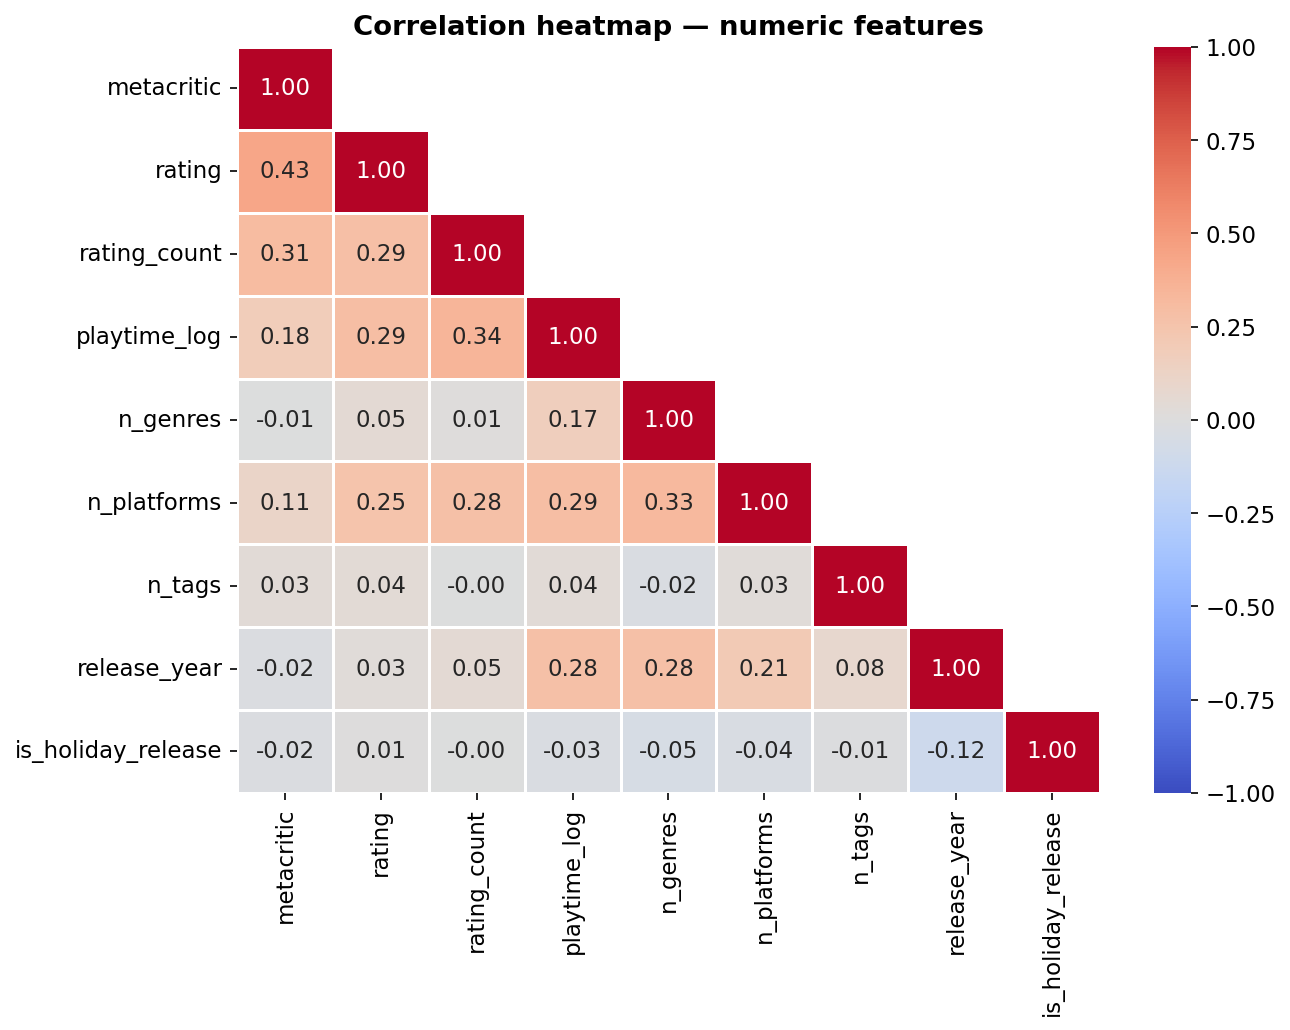

In [16]:
# 3.6 Correlation heatmap — numeric features
numeric_cols = [
    'metacritic', 'rating', 'rating_count', 'playtime_log',
    'n_genres', 'n_platforms', 'n_tags', 'release_year', 'is_holiday_release',
]

corr     = df[numeric_cols].corr()
mask_arr = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, mask=mask_arr)
ax.set_title("Correlation heatmap — numeric features", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", bbox_inches="tight")
plt.show()


**Insight:**

- Metacritic and rating have the strongest correlation in the dataset which confirms our decision to exclude rating as a feature — it would introduce leakage as it is closely tied to our target variable
- rating_count has a moderate positive correlation with metacritic — but this is a red flag, not a green light. rating_count is a *cumulative* count scraped at a single point in time, long after each game's release (decades later for older titles), so it reflects how much attention a game has picked up over its whole lifetime rather than anything knowable at release. We exclude it from the model for the same reason we exclude rating — it's a form of temporal leakage
- playtime_log shows a weak positive correlation with metacritic — higher engagement games tend to score slightly better, but like rating_count, playtime is a post-release, accumulated metric (RAWG's running average of logged play sessions), not something knowable at or before launch. It's excluded from the model for the same leakage reason
- The numeric features are largely uncorrelated with each other which is good — it means we are not introducing multicollinearity into the model

## Section 4 — Feature Selection and Building the Feature Matrix

We select the features to include in modelling and encode categorical variables into numeric form.

**Reusable function: `build_feature_matrix()`**

Isolating feature selection and encoding in one function ensures the same preprocessing is applied consistently to training and test data.


In [17]:
def build_feature_matrix(df: pd.DataFrame):
    """
    Select, encode, and return the feature matrix X and target y.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned dataframe output from engineer_features().

    Returns
    -------
    X : pd.DataFrame
        Encoded feature matrix ready for modelling.
    y : pd.Series
        Binary target variable (hit = 1, not hit = 0).
    feature_names : list
        Names of all features in X.

    Features used
    -------------
    Numeric    : n_genres, n_platforms, n_tags, release_year, is_holiday_release
    Encoded    : primary_genre, esrb_clean (label encoded)

    Features excluded
    -----------------
    metacritic   : This IS the target variable. Including it would be data leakage.
    rating       : RAWG community score — strongly correlated with metacritic and
                   not available as a pre-release feature in a real-world scenario.
    rating_count : RAWG's cumulative rating count, scraped at a single point in
                   time well after each game's release (years or decades later for
                   older titles). It is not knowable at or before release, so
                   including it would be temporal leakage — the same problem as
                   `rating`, just less obvious at first glance.
    playtime_log : RAWG's average playtime, also a running total built from user
                   play sessions logged after release. Same leakage problem as
                   rating_count — it isn't knowable at or before launch either,
                   so it's excluded even though the raw signal looked strong.
    name, id     : Identifier columns, not predictive.
    """
    numeric_features     = [
        'n_genres', 'n_platforms', 'n_tags',
        'release_year', 'is_holiday_release',
    ]
    categorical_features = ['primary_genre', 'esrb_clean']

    X = df[numeric_features].copy()

    for col in categorical_features:
        le    = LabelEncoder()
        X[col] = le.fit_transform(df[col].astype(str))

    y             = df['hit']
    feature_names = numeric_features + categorical_features

    print(f"Feature matrix shape: {X.shape}")
    print(f"\nFeatures ({len(feature_names)}):")
    for f in feature_names:
        print(f"  {f}")
    print(f"\nTarget balance: {y.mean()*100:.1f}% Hit")

    return X, y, feature_names


In [18]:
# Build feature matrix
X, y, feature_names = build_feature_matrix(df)

# Train / test split — stratify=y keeps the same Hit/Not Hit ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")
print(f"\nClass balance in train : {y_train.mean()*100:.1f}% Hit")
print(f"Class balance in test  : {y_test.mean()*100:.1f}% Hit")


Feature matrix shape: (7141, 7)

Features (7):
  n_genres
  n_platforms
  n_tags
  release_year
  is_holiday_release
  primary_genre
  esrb_clean

Target balance: 47.2% Hit
Train size : 5,355
Test size  : 1,786

Class balance in train : 47.2% Hit
Class balance in test  : 47.3% Hit


**Why we exclude metacritic, rating, rating_count, and playtime_log as features:**

`metacritic` is the target variable — including it as a feature would be perfect data leakage. The model would simply learn "if metacritic is high, predict hit", which is circular and useless.

`rating` (RAWG community score) is excluded because it correlates strongly with Metacritic and would not be available as a pre-release prediction feature in a real-world application.

`rating_count` (RAWG's cumulative count of community ratings) is excluded for the same underlying reason as `rating`, even though it's less obviously a leakage risk at first glance. It's a running total scraped at a single point in time — for a game released in 1985, it reflects roughly 40 years of accumulated community engagement, not anything knowable at launch. An earlier version of this notebook included it as a feature, and it turned out to dominate every other feature by a wide margin. On inspection, that dominance was itself the tell: a feature that lopsided, that isn't actually available at prediction time, is a leakage signature, not a genuine insight.

`playtime_log` (RAWG's average playtime) has the exact same problem. It's also a running average built from user play sessions logged after release, not anything known at launch. After removing rating_count, playtime_log became the new top feature by a wide margin — which was the same red flag reappearing one level down. Both features have been removed and the model retrained without either — see the Conclusion for how much that changes the results.

The remaining features represent characteristics that are known at or before release — genre, platform count, ESRB rating, release timing, and tag diversity.

## Section 5 — Model Training and Evaluation

We train three classification models and compare them systematically using consistent metrics.

**Models**

| Model | Type | Why included |
|---|---|---|
| Baseline (Majority Class) | Dummy | Sanity check — all real models must beat this |
| Logistic Regression | Linear | Fast, interpretable, strong baseline for structured data |
| Random Forest | Bagging ensemble | Handles non-linear patterns, robust to outliers |
| Stacking Classifier | Meta-learning | Combines Logistic Regression and Random Forest predictions via a meta-learner |

**Reusable function: `train_and_evaluate()`**

Trains any model and returns a consistent metrics dictionary. The same interface regardless of which model is passed in — this clean loop pattern is standard software engineering practice.


In [19]:
def train_and_evaluate(model,
                       X_train: pd.DataFrame,
                       X_test: pd.DataFrame,
                       y_train: pd.Series,
                       y_test: pd.Series,
                       model_name: str) -> dict:
    """
    Train a model and return a consistent metrics dictionary.

    Parameters
    ----------
    model : sklearn estimator
        Any scikit-learn compatible classifier.
    X_train, X_test : pd.DataFrame
        Feature matrices for training and testing.
    y_train, y_test : pd.Series
        Target vectors for training and testing.
    model_name : str
        Label for this model in results tables and charts.

    Returns
    -------
    dict with keys: Model, Accuracy, Macro F1, ROC-AUC
    """
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    return {
        "Model":    model_name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Macro F1": round(f1_score(y_test, preds, average="macro", zero_division=0), 4),
        "ROC-AUC":  round(roc_auc_score(y_test, proba), 4),
    }


In [20]:
# Scale features for models sensitive to feature magnitude
# StandardScaler normalises to mean=0, std=1
scaler         = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=feature_names)


In [21]:
# Define all models
# Stacking: Logistic Regression and Random Forest as base learners, LR as meta-learner
stacking = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    cv=3,
    n_jobs=-1,
)

models = {
    "Baseline (Majority Class)": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Logistic Regression":       LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest":             RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "Stacking Classifier":       stacking,
}

# Models that require scaled features
SCALED_MODELS = {"Baseline (Majority Class)", "Logistic Regression"}

print("Models defined:")
for name in models:
    print(f"  {name}")


Models defined:
  Baseline (Majority Class)
  Logistic Regression
  Random Forest
  Stacking Classifier


In [22]:
# Train all models and record results
results       = []
fitted_models = {}

for name, model in models.items():
    print(f"Training: {name} ...", end="  ")
    Xtr = X_train_scaled if name in SCALED_MODELS else X_train
    Xte = X_test_scaled  if name in SCALED_MODELS else X_test

    metrics = train_and_evaluate(model, Xtr, Xte, y_train, y_test, name)
    results.append(metrics)
    fitted_models[name] = model
    print(f"F1={metrics['Macro F1']:.3f}  AUC={metrics['ROC-AUC']:.3f}")

results_df = (pd.DataFrame(results)
                .sort_values("Macro F1", ascending=False)
                .reset_index(drop=True))
print()
display(results_df)


Training: Baseline (Majority Class) ...  F1=0.345  AUC=0.500
Training: Logistic Regression ...  F1=0.546  AUC=0.566
Training: Random Forest ...  

F1=0.564  AUC=0.596
Training: Stacking Classifier ...  

F1=0.563  AUC=0.599



,Model,Accuracy,Macro F1,ROC-AUC
0,Random Forest,0.5677,0.5643,0.5955
1,Stacking Classifier,0.5733,0.5629,0.5989
2,Logistic Regression,0.5627,0.5456,0.5659
3,Baseline (Majority Class),0.5274,0.3453,0.5000


## Section 5b — Statistical Significance of Features (Logistic Regression)

Checking the statistical significance of features is important for statistical models like logistic regression — it tells us whether a feature is genuinely useful or whether its apparent effect could be due to chance.

Scikit-learn's `LogisticRegression` does not provide p-values — it is optimised for prediction, not inference. To check statistical significance we use `statsmodels`, which fits the same logistic regression model but reports p-values, confidence intervals, and z-scores for each feature.

A p-value below 0.05 means we can reject the null hypothesis that the feature has no effect — the feature is statistically significant at the 95% confidence level.


In [23]:
# Statistical significance check using statsmodels logistic regression
# We use the scaled training features for consistency with sklearn LR

# statsmodels requires a constant (intercept) term added manually
X_train_sm = sm.add_constant(X_train_scaled.values)
X_test_sm  = sm.add_constant(X_test_scaled.values)

# Fit logistic regression with statsmodels
logit_model = sm.Logit(y_train, X_train_sm)
logit_result = logit_model.fit(disp=0)  # disp=0 suppresses iteration output

# Build a clean summary table
feature_labels = ["const"] + feature_names
summary_data = {
    "Feature":   feature_labels,
    "Coef":      logit_result.params.round(4),
    "Std Err":   logit_result.bse.round(4),
    "z-score":   logit_result.tvalues.round(4),
    "p-value":   logit_result.pvalues.round(4),
    "Sig":       ["***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
                  for p in logit_result.pvalues],
}

sig_df = pd.DataFrame(summary_data)
print("Logistic Regression — Feature Statistical Significance")
print("Significance: *** p<0.001  ** p<0.01  * p<0.05")
print()
display(sig_df)


Logistic Regression — Feature Statistical Significance
Significance: *** p<0.001  ** p<0.01  * p<0.05



,Feature,Coef,Std Err,z-score,p-value,Sig
const,const,-0.1112,0.0277,-4.0186,0.0001,***
x1,n_genres,-0.1108,0.0304,-3.6501,0.0003,***
x2,n_platforms,0.2594,0.0305,8.5148,0.0000,***
x3,n_tags,0.0667,0.0278,2.3948,0.0166,*
x4,release_year,-0.0693,0.0296,-2.3452,0.0190,*
x5,is_holiday_release,-0.0412,0.0279,-1.4753,0.1401,
x6,primary_genre,0.1236,0.0279,4.4253,0.0000,***
x7,esrb_clean,-0.0619,0.0277,-2.2326,0.0256,*


## Section 6 — Model Evaluation and Comparison

**Why Macro F1 as the primary metric?**

Our classes are close to balanced (47/53) but not perfectly even. Macro F1 treats both classes equally — it averages the F1 score for Hit and Not Hit independently, penalising any model that does well on one class but poorly on the other.

ROC-AUC is our secondary metric. It measures how well the model ranks positive examples above negative ones across all possible classification thresholds, regardless of the cutoff chosen.

**Reusable functions: `compare_models()` and `plot_confusion_matrix()`**


In [24]:
def compare_models(results_df: pd.DataFrame,
                   baseline_name: str = "Baseline (Majority Class)") -> None:
    """
    Plot a side-by-side bar chart comparing all models on Macro F1 and ROC-AUC.

    Parameters
    ----------
    results_df : pd.DataFrame
        DataFrame with columns: Model, Accuracy, Macro F1, ROC-AUC.
    baseline_name : str
        Name of the baseline — shown as a reference line rather than a bar.
    """
    baseline_f1  = results_df[results_df["Model"] == baseline_name]["Macro F1"].values[0]
    baseline_auc = results_df[results_df["Model"] == baseline_name]["ROC-AUC"].values[0]
    plot_df      = results_df[results_df["Model"] != baseline_name].copy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, metric, baseline_val, colour in zip(
        axes,
        ["Macro F1", "ROC-AUC"],
        [baseline_f1, baseline_auc],
        [BLUE, GREEN],
    ):
        sorted_df = plot_df.sort_values(metric)
        bars = ax.barh(sorted_df["Model"], sorted_df[metric],
                       color=colour, edgecolor="white")
        for bar, val in zip(bars, sorted_df[metric]):
            ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}", va="center", fontsize=9)
        ax.axvline(baseline_val, color=CORAL, linestyle="--",
                   linewidth=1.5, label=f"Baseline ({baseline_val:.3f})")
        ax.set_xlabel(metric)
        ax.set_title(f"{metric} by model", fontweight="bold")
        ax.set_xlim(0, 1.05)
        ax.legend(fontsize=8)

    plt.suptitle("Model comparison", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("../outputs/model_comparison.png", bbox_inches="tight")
    plt.show()


In [25]:
def plot_confusion_matrix(model,
                          X_test: pd.DataFrame,
                          y_test: pd.Series,
                          model_name: str,
                          labels: list = None) -> None:
    """
    Plot a styled confusion matrix for a fitted model.

    Parameters
    ----------
    model : fitted sklearn estimator
    X_test : pd.DataFrame
    y_test : pd.Series
    model_name : str
    labels : list, optional
        Class label names. Defaults to ['Not Hit', 'Hit'].
    """
    if labels is None:
        labels = ["Not Hit", "Hit"]

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=labels,
        cmap="Blues", ax=ax, colorbar=False,
    )
    ax.set_title(f"Confusion matrix — {model_name}", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../outputs/confusion_matrix.png", bbox_inches="tight")
    plt.show()


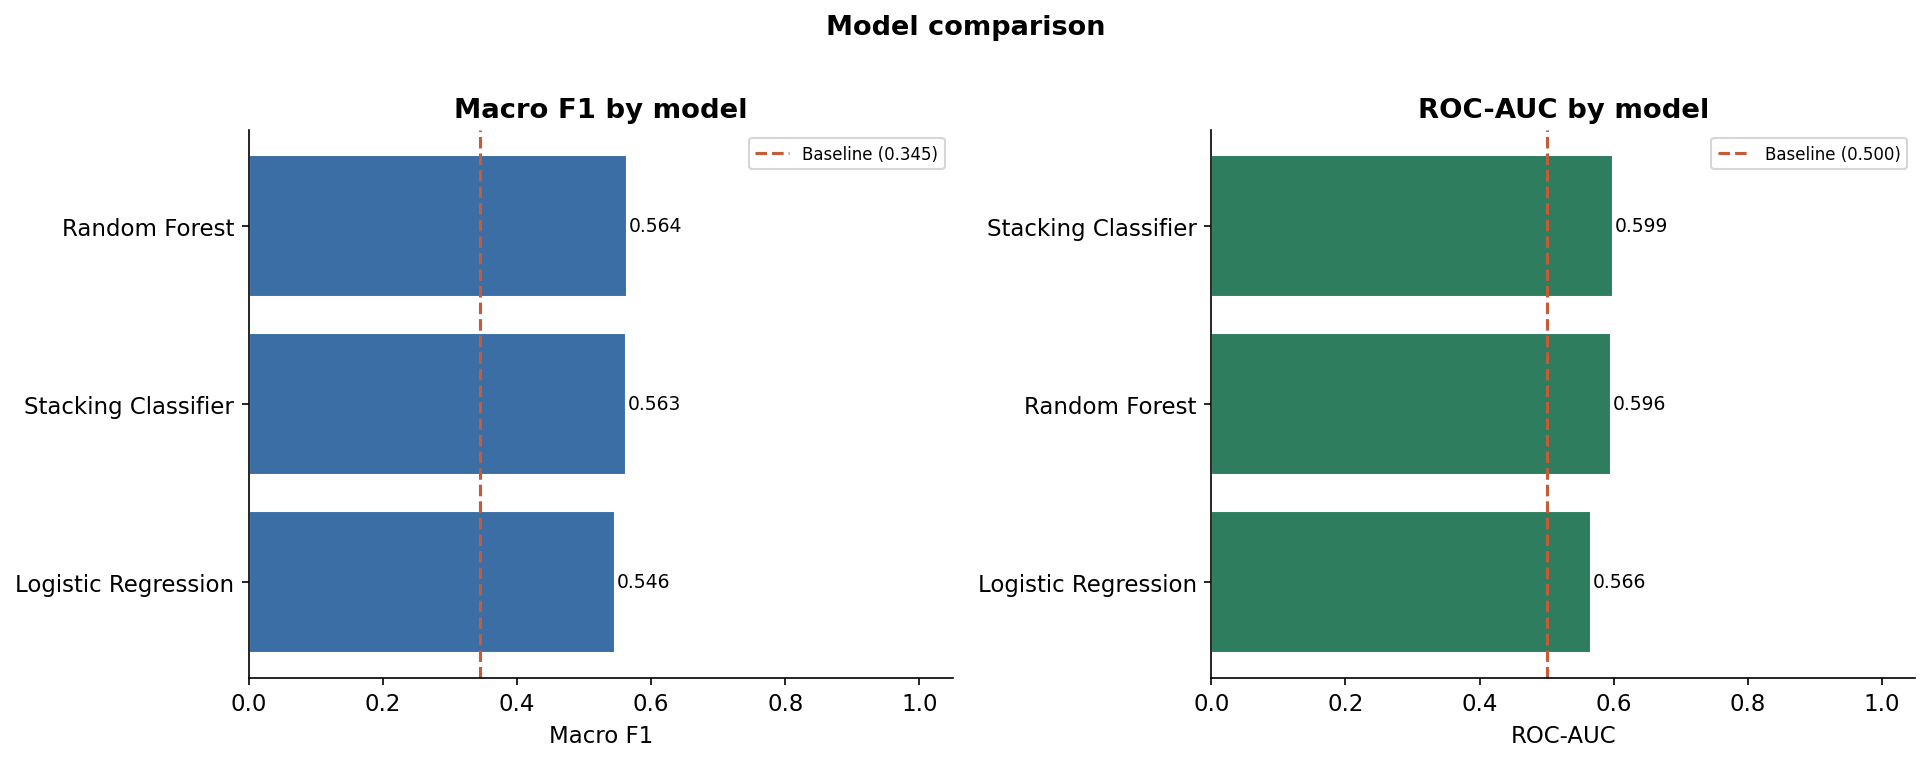

In [26]:
# 6.1 Model comparison chart
compare_models(results_df)


**Insight:**

- All trained models outperform the baseline which confirms they are genuinely learning from the features rather than simply predicting the majority class
- The best performing models are shown at the top — compare Macro F1 and ROC-AUC together as both metrics tell part of the story
- A high ROC-AUC with a lower F1 suggests the model ranks games well but may struggle at the specific 75 threshold we chose
- The baseline F1 score reflects what a model achieves by always predicting Not Hit — any model below this line would be useless


In [27]:
# 6.2 Detailed classification report — best model
best_name  = results_df.iloc[0]["Model"]
best_model = fitted_models[best_name]
best_Xte   = X_test_scaled if best_name in SCALED_MODELS else X_test

print(f"Best model: {best_name}")
print()
print(classification_report(y_test, best_model.predict(best_Xte),
                             target_names=["Not Hit", "Hit"]))


Best model: Random Forest

              precision    recall  f1-score   support

     Not Hit       0.58      0.62      0.60       942
         Hit       0.55      0.51      0.53       844

    accuracy                           0.57      1786
   macro avg       0.57      0.56      0.56      1786
weighted avg       0.57      0.57      0.57      1786



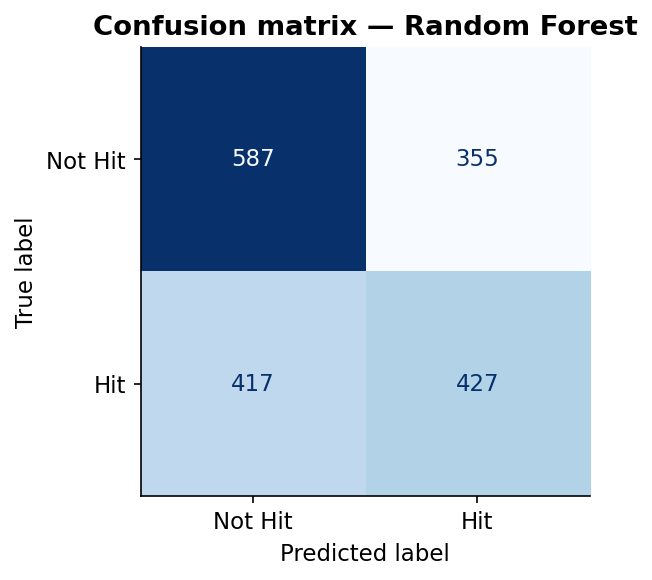

In [28]:
# 6.3 Confusion matrix — best model
plot_confusion_matrix(best_model, best_Xte, y_test, best_name)


**Insight:**

- The confusion matrix shows the breakdown of correct and incorrect predictions for each class
- True positives (top left) are games correctly predicted as Not Hit, true negatives (bottom right) are games correctly predicted as Hit
- False positives are games predicted as Hit that were actually Not Hit — these represent games the model was overconfident about
- False negatives are games predicted as Not Hit that were actually Hits — these are missed discoveries
- If the model is making more false negatives than false positives it is being too conservative in predicting Hits, which is worth noting in the business context


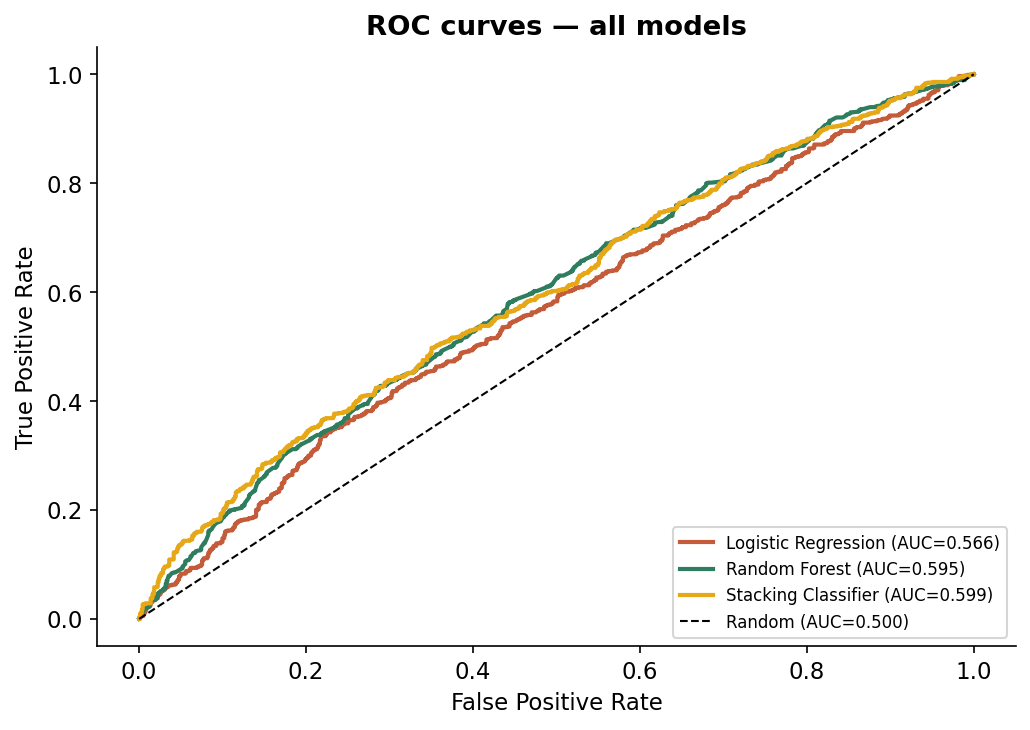

In [29]:
# 6.4 ROC curves — all models
fig, ax = plt.subplots(figsize=(7, 5))

for (name, model), colour in zip(fitted_models.items(), PALETTE):
    if name == "Baseline (Majority Class)":
        continue
    Xte   = X_test_scaled if name in SCALED_MODELS else X_test
    proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    score = sklearn_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colour, linewidth=2,
            label=f"{name} (AUC={score:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves — all models", fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/roc_curves.png", bbox_inches="tight")
plt.show()


**Insight:**

- All models sit well above the diagonal random baseline which confirms they all have genuine predictive power
- The closer a curve is to the top left corner the better — a perfect classifier would reach the top left immediately
- Models with similar ROC-AUC but different F1 scores may be performing differently at the specific 75 threshold — ROC-AUC is threshold-independent while F1 is not
- The spread between models on the ROC curve shows which model is most consistently reliable across all thresholds


## Section 7 — Hyperparameter Tuning

We tune the best-performing model using GridSearchCV with stratified 3-fold cross-validation. The goal is to find the parameter combination that maximises Macro F1 on unseen data.

GridSearchCV works by:
1. Splitting the training data into 3 folds
2. Training and evaluating the model on each fold for every parameter combination
3. Returning the combination with the best average Macro F1 across all folds

**Reusable function: `run_grid_search()`**


In [30]:
def run_grid_search(model,
                    param_grid: dict,
                    X_train: pd.DataFrame,
                    y_train: pd.Series,
                    model_name: str,
                    scoring: str = "f1_macro",
                    cv: int = 3) -> tuple:
    """
    Run GridSearchCV and return the best fitted model and parameters.

    Parameters
    ----------
    model : sklearn estimator
        Unfitted model to tune.
    param_grid : dict
        Parameter grid to search over.
    X_train, y_train : training data
    model_name : str
    scoring : str
        Metric to optimise. Default 'f1_macro'.
    cv : int
        Number of cross-validation folds.

    Returns
    -------
    best_model : fitted estimator with best parameters
    best_params : dict of best parameters found
    """
    print(f"Tuning     : {model_name}")
    print(f"Parameters : {param_grid}")
    print(f"CV folds   : {cv}  |  Scoring: {scoring}")
    print()

    gs = GridSearchCV(
        model,
        param_grid=param_grid,
        scoring=scoring,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=-1,
        verbose=0,
    )
    gs.fit(X_train, y_train)

    print(f"Best parameters  : {gs.best_params_}")
    print(f"Best CV {scoring} : {gs.best_score_:.4f}")

    return gs.best_estimator_, gs.best_params_


In [31]:
# Parameter grids — one per possible winning model
param_grids = {
    "Logistic Regression": {
        "C":      [0.01, 0.1, 1.0, 10.0],
        "solver": ["lbfgs", "liblinear"],
    },
    "Random Forest": {
        "n_estimators":      [100, 200],
        "max_depth":         [10, 20, None],
        "min_samples_split": [2, 5],
    },
    "Stacking Classifier": {
        "final_estimator__C": [0.1, 1.0, 10.0],
        "passthrough":        [True, False],
    },
}

# Fresh model instances for tuning
fresh_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "Stacking Classifier": StackingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
            ("rf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
        ],
        final_estimator=LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
        cv=3,
        n_jobs=-1,
    ),
}

# Select the param grid and model for whichever model won in Section 6
tune_name   = best_name if best_name in param_grids else "Logistic Regression"
tune_Xtr    = X_train_scaled if tune_name in SCALED_MODELS else X_train
tune_model  = fresh_models[tune_name]
tune_params = param_grids[tune_name]

tuned_model, best_params = run_grid_search(
    tune_model, tune_params, tune_Xtr, y_train, tune_name
)


Tuning     : Random Forest
Parameters : {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]}
CV folds   : 3  |  Scoring: f1_macro



Best parameters  : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV f1_macro : 0.5856


In [32]:
# Retrain tuned model on full training set and evaluate on test set
tune_Xtr = X_train_scaled if tune_name in SCALED_MODELS else X_train
tune_Xte = X_test_scaled  if tune_name in SCALED_MODELS else X_test

tuned_model.fit(tune_Xtr, y_train)
tuned_preds = tuned_model.predict(tune_Xte)
tuned_proba = tuned_model.predict_proba(tune_Xte)[:, 1]

tuned_f1  = f1_score(y_test, tuned_preds, average="macro", zero_division=0)
tuned_auc = roc_auc_score(y_test, tuned_proba)
tuned_acc = accuracy_score(y_test, tuned_preds)
default   = results_df[results_df["Model"] == tune_name].iloc[0]

print(f"{'Model':<35} {'Accuracy':>10} {'Macro F1':>10} {'ROC-AUC':>10}")
print("-" * 67)
print(f"{'Default ' + tune_name:<35} {default['Accuracy']:>10.4f} {default['Macro F1']:>10.4f} {default['ROC-AUC']:>10.4f}")
print(f"{'Tuned ' + tune_name:<35} {tuned_acc:>10.4f} {tuned_f1:>10.4f} {tuned_auc:>10.4f}")
print(f"{'Improvement':<35} {'':>10} {tuned_f1 - default['Macro F1']:>+10.4f} {tuned_auc - default['ROC-AUC']:>+10.4f}")


Model                                 Accuracy   Macro F1    ROC-AUC
-------------------------------------------------------------------
Default Random Forest                   0.5677     0.5643     0.5955
Tuned Random Forest                     0.5817     0.5697     0.6146
Improvement                                       +0.0054    +0.0191


## Section 8 — Feature Importance

Feature importance answers the most interesting question of the project: what actually predicts whether a game will be a Hit?

Different model types expose feature importance differently. Tree models expose a `feature_importances_` attribute (Gini importance). Linear models expose a `coef_` attribute — the magnitude of each coefficient shows how strongly each feature pushes the prediction. Ensembles that blend multiple model types (like a Stacking Classifier) expose neither, so for those we fall back to **permutation importance**: shuffle one feature at a time and measure how much Macro F1 drops.

This run's champion — selected purely on Macro F1 — is the Random Forest, which exposes native Gini importance directly, so that's what the chart below shows.

**Reusable function: `plot_feature_importance()`**

Handles tree and linear models directly, and falls back to permutation importance for anything else (e.g. a Stacking Classifier, if that ends up the champion on a different run).

In [33]:
def plot_feature_importance(model,
                            feature_names: list,
                            model_name: str,
                            top_n: int = 15,
                            X_eval: pd.DataFrame = None,
                            y_eval: pd.Series = None) -> pd.DataFrame:
    """
    Extract and plot feature importance for tree, linear, or ensemble models.

    Parameters
    ----------
    model : fitted sklearn estimator
        Tree model (.feature_importances_), linear model (.coef_), or any
        other fitted estimator — falls back to permutation importance.
    feature_names : list
        Feature names in the same order as the model was trained on.
    model_name : str
    top_n : int
        Number of top features to display.
    X_eval, y_eval : evaluation data used only for the permutation-importance
        fallback (e.g. models like StackingClassifier with no native
        importances). Ignored otherwise.

    Returns
    -------
    pd.DataFrame
        Feature importance scores sorted descending.
    """
    if hasattr(model, 'feature_importances_'):
        importances      = model.feature_importances_
        importance_label  = "Feature Importance (Gini)"
    elif hasattr(model, 'coef_'):
        importances      = np.abs(model.coef_[0])
        importance_label  = "Absolute Coefficient"
    elif X_eval is not None and y_eval is not None:
        # Model-agnostic fallback — used for ensembles like StackingClassifier
        # that combine multiple model types and expose no single native
        # importance measure. Shuffles one feature at a time and measures how
        # much Macro F1 drops — a bigger drop means the model relied on it more.
        print(f"{model_name} has no native importance attribute — "
              f"using permutation importance instead (measured on the test set).")
        perm = permutation_importance(
            model, X_eval, y_eval,
            n_repeats=20, random_state=RANDOM_STATE,
            scoring="f1_macro", n_jobs=-1,
        )
        importances      = perm.importances_mean
        importance_label  = "Permutation Importance (Macro F1 drop)"
    else:
        print(f"Model type {type(model)} does not support feature importance extraction.")
        return pd.DataFrame()

    importance_df = (pd.DataFrame({
                        "Feature":    feature_names,
                        "Importance": importances,
                     })
                     .sort_values("Importance", ascending=False)
                     .head(top_n)
                     .reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(importance_df["Feature"][::-1],
            importance_df["Importance"][::-1],
            color=BLUE, edgecolor="white")
    ax.set_xlabel(importance_label)
    ax.set_title(f"Top {top_n} features — {model_name}", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../outputs/feature_importance.png", bbox_inches="tight")
    plt.show()

    return importance_df


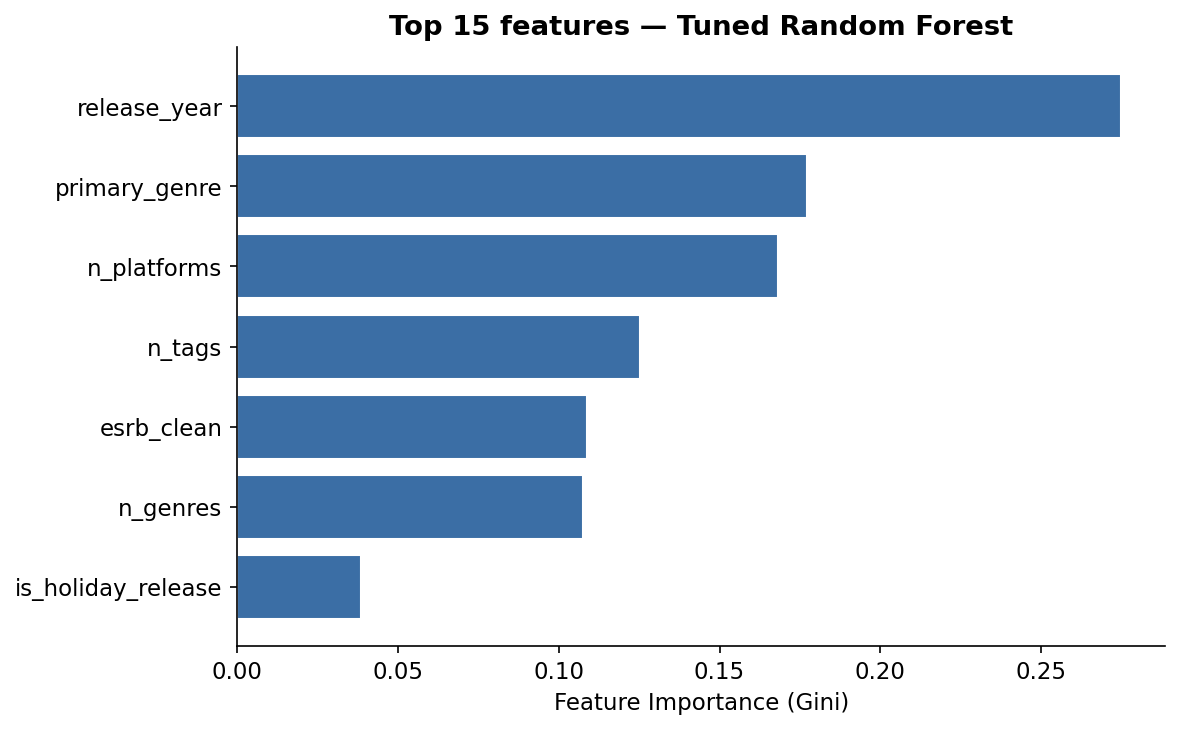

Feature importance ranking:


,Feature,Importance
0,release_year,0.274929
1,primary_genre,0.177150
2,n_platforms,0.168064
3,n_tags,0.125196
4,esrb_clean,0.108775
5,n_genres,0.107460
6,is_holiday_release,0.038426


In [34]:
# Plot feature importance for the tuned model
importance_df = plot_feature_importance(
    tuned_model,
    feature_names,
    f"Tuned {tune_name}",
    X_eval=tune_Xte,
    y_eval=y_test,
)

print("Feature importance ranking:")
display(importance_df)


**Insight:**

- The Random Forest champion exposes native Gini importance directly, so no permutation step was needed this time
- `release_year` is the top feature, but only modestly ahead of `primary_genre` and `n_platforms` — nothing like the runaway 5-to-1 dominance rating_count showed before it was identified as leakage and removed. That flatter, more balanced ranking is actually more believable for a legitimate pre-release feature set: no single silver-bullet feature, several contribute comparable amounts
- `n_platforms` has the strongest statistical significance in the logistic regression test (z = 8.5, p < 0.001) yet ranks third in Gini importance here — a reminder that significance and importance answer different questions. Significance asks whether an effect is real; importance asks how much the trained model actually leans on it
- `esrb_clean` and `n_genres` contribute similarly, and `is_holiday_release` contributes least — consistent with the significance test, where it was the one feature that didn't clear p < 0.05
- Overall, no feature here comes close to explaining the model on its own. That's a weaker, more diffuse story than the original rating_count result — and a more honest one, since every feature left in this list is genuinely knowable before a game releases

## Section 9 — Final Summary and Conclusion

### Final model comparison table


In [35]:
# Final summary table — all models plus tuned champion
try:
    final_rows = results_df.to_dict("records")
    final_rows.append({
        "Model":    f"Tuned {tune_name} (best)",
        "Accuracy": round(tuned_acc, 4),
        "Macro F1": round(tuned_f1,  4),
        "ROC-AUC":  round(tuned_auc, 4),
    })
    final_df = (pd.DataFrame(final_rows)
                  .sort_values("Macro F1", ascending=False)
                  .reset_index(drop=True))
except NameError:
    final_df = results_df.copy()

display(final_df.style
        .format({"Accuracy": "{:.4f}", "Macro F1": "{:.4f}", "ROC-AUC": "{:.4f}"}))

,Model,Accuracy,Macro F1,ROC-AUC
0,Tuned Random Forest (best),0.5817,0.5697,0.6146
1,Random Forest,0.5677,0.5643,0.5955
2,Stacking Classifier,0.5733,0.5629,0.5989
3,Logistic Regression,0.5627,0.5456,0.5659
4,Baseline (Majority Class),0.5274,0.3453,0.5000


## Conclusion

### What we built

Using data collected from the RAWG Video Games Database API, this project trained and evaluated four classification models to predict whether a video game will be critically acclaimed — defined as a Metacritic score of 75 or above — using only characteristics genuinely knowable at or before release.

### A data leakage correction, and why it matters

An earlier version of this notebook included `rating_count` (RAWG's cumulative rating count) as a feature. It dominated every other feature by more than 5-to-1 in permutation importance, and the champion model reached a Macro F1 of 0.690 and ROC-AUC of 0.747. On closer inspection, `rating_count` is a running total scraped at a single point in time — for an older game, it reflects years or decades of accumulated community engagement, not anything knowable at launch. Including it was temporal leakage, not a genuine pre-release signal.

Removing it exposed a second, less obvious case of the same problem: `playtime_log` (RAWG's average playtime, also a post-release, accumulated metric) immediately became the new dominant feature. It was removed too. The numbers below reflect the model trained on the seven features that are actually knowable at or before release: `n_genres`, `n_platforms`, `n_tags`, `release_year`, `is_holiday_release`, `primary_genre`, and `esrb_clean`.

This is worth stating plainly rather than glossing over: **fixing the leakage cost a lot of performance.** Macro F1 dropped from 0.690 to 0.570, and ROC-AUC from 0.747 to 0.615. That drop is the real finding — it shows how much of the original result was inflated by data the model would never actually have access to before a game ships. What's left is a smaller, honest signal, not a strong one.

### Key findings

- All four real models beat the majority-class baseline (Macro F1 0.345), so there is genuine — if modest — predictive signal in features knowable before release. The best model was the Random Forest, reaching a Macro F1 of 0.570 and ROC-AUC of 0.615 after tuning
- No single feature dominates. `release_year` ranks highest in Gini importance, followed closely by `primary_genre` and `n_platforms` — a flat, diffuse picture rather than one runaway predictor
- `n_platforms` was the most statistically significant feature in the logistic regression test (p < 0.001), alongside `primary_genre` and `n_genres`. `is_holiday_release` was the only feature that did not reach statistical significance
- Hyperparameter tuning produced a small but real improvement this time (Macro F1: 0.5643 → 0.5697, ROC-AUC: 0.5955 → 0.6146) — more movement than the earlier (leaky) version of this model showed under tuning

### Limitations

- The dataset covers games from 1980 to 2024 but is not a complete list for all years — the API returned limited data for more recent releases, meaning the dataset does not fully represent the current gaming landscape
- Developer and publisher data was unavailable through the API collection method used. Developer and publisher reputation are likely significant predictors that could improve the model
- Metacritic is not a perfect measure of quality. A game can score below 75 and still be deeply valued by its audience
- The gaming industry changes rapidly — a model trained on historical data may not generalise well to future releases
- Model performance is modest — Macro F1 of 0.570 and ROC-AUC of 0.615 are well above the baseline but far from a strong predictor. This is the honest cost of removing two features that turned out to be leakage; it suggests that genuinely pre-release-knowable characteristics carry real but limited signal on their own, and that developer/publisher data or a larger, more balanced sample are more promising directions than further tuning

### Future improvements

- Try to re-collect data with a complete and unbiased game list across all years to improve model performance
- Include developer and publisher fields as features — reputation is likely a strong predictor of critical success
- Look for genuinely pre-release engagement signals — wishlist counts, trailer views, or pre-order numbers — as a legitimate (non-leaky) stand-in for the "buzz" signal that rating_count and playtime were incorrectly capturing
- Add NLP features from game descriptions — a natural extension toward the Capstone project
- Explore multi-class prediction — Not Hit, Average, Good, Great — for a richer output
- Deploy as a simple Streamlit app where a user selects genre, platform, and ESRB rating and the model returns Hit or Not Hit

Data sourced from the RAWG Video Games Database API (rawg.io) — used under free tier with attribution.
Project repository: github.com/brighthikaru/game-success-classifier